# LightGBM PetFinder mejorado

Esta versión es más robusta que la versión corta inicial.

Incluye:

- feature engineering más amplio;
- labels auxiliares si existen (`breed_labels.csv`, `color_labels.csv`, `state_labels.csv`);
- features de texto simples sin BERT;
- agregados calculados solo sobre train para evitar fuga de información;
- validación cruzada estratificada;
- Optuna opcional;
- métricas y gráficos;
- guardado compatible con la integración LightGBM + BERT.

Salida clave:

```text
work/optuna_artifacts/lgb_test_predictions.joblib
```


In [1]:
# ============================================================
# LightGBM PetFinder - versión mejorada para TP e integración con BERT
#
# Objetivo:
# 1) Entrenar un modelo tabular fuerte con LightGBM.
# 2) Usar el mismo split test_petids.joblib que BERT.
# 3) Hacer feature engineering más completo.
# 4) Usar validación cruzada estratificada.
# 5) Opcionalmente usar Optuna para buscar hiperparámetros.
# 6) Guardar predicciones compatibles con el notebook de integración.
# 7) Generar gráficos y tablas para explicar el modelo.
#
# Salidas principales:
#   work/optuna_artifacts/test_petids.joblib
#   work/optuna_artifacts/lgb_test_predictions.joblib
#   work/optuna_artifacts/lgb_oof_predictions.joblib
#   work/models_lgbm_enhanced/lgbm_fold_models.joblib
#   work/lgbm_enhanced_results/
# ============================================================

from pathlib import Path
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
from joblib import dump, load

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    cohen_kappa_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
)

try:
    import lightgbm as lgb
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "No está instalado lightgbm. Instálalo con:\n"
        "conda activate ldi2_cuda2\n"
        "conda install -c conda-forge lightgbm -y"
    ) from exc




In [2]:
# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

warnings.filterwarnings("ignore")

SEED = 42
TEST_SIZE = 0.20
NUM_CLASSES = 5
CLASS_LABELS = list(range(NUM_CLASSES))

# Validación cruzada
N_SPLITS = 5

# Optuna opcional.
# Para empezar, recomiendo dejarlo en False.
# Cuando ya verifiques que todo corre, puedes probar True con 20 o 30 trials.
RUN_OPTUNA = False
OPTUNA_N_TRIALS = 25
OPTUNA_N_SPLITS = 3
OPTUNA_NUM_BOOST_ROUND = 800
OPTUNA_EARLY_STOPPING = 60

# Entrenamiento final
NUM_BOOST_ROUND = 2500
EARLY_STOPPING_ROUNDS = 120

# Tu ruta real del proyecto
BASE_DIR = Path(r"C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction")

PATH_TO_TRAIN = BASE_DIR / "train" / "train.csv"

WORK_DIR = BASE_DIR / "work"
PATH_TO_ARTIFACTS = WORK_DIR / "optuna_artifacts"
PATH_TO_MODELS = WORK_DIR / "models_lgbm_enhanced"
RESULTS_DIR = WORK_DIR / "lgbm_enhanced_results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

for p in [WORK_DIR, PATH_TO_ARTIFACTS, PATH_TO_MODELS, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PATH_TO_TEST_IDS = PATH_TO_ARTIFACTS / "test_petids.joblib"

PATH_LGB_TEST_PREDS = PATH_TO_ARTIFACTS / "lgb_test_predictions.joblib"
PATH_LGB_OOF_PREDS = PATH_TO_ARTIFACTS / "lgb_oof_predictions.joblib"
PATH_LGB_MODELS = PATH_TO_MODELS / "lgbm_fold_models.joblib"
PATH_LGB_METRICS = RESULTS_DIR / "lgbm_metrics.json"
PATH_FEATURE_IMPORTANCE = TABLES_DIR / "feature_importance.csv"
PATH_FOLD_METRICS = TABLES_DIR / "fold_metrics.csv"
PATH_OOF_PREVIEW = TABLES_DIR / "lgb_oof_predictions_preview.csv"
PATH_TEST_PREVIEW = TABLES_DIR / "lgb_test_predictions_preview.csv"

# Parámetros base. Si RUN_OPTUNA=True, estos se reemplazan por los mejores encontrados.
DEFAULT_LGB_PARAMS = {
    "objective": "multiclass",
    "num_class": NUM_CLASSES,
    "metric": "multi_logloss",
    "boosting_type": "gbdt",
    "verbosity": -1,
    "seed": SEED,
    "learning_rate": 0.03,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.85,
    "subsample_freq": 5,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.3,
    "reg_lambda": 1.5,
    "min_split_gain": 0.0,
}




In [3]:
# ============================================================
# 2. UTILIDADES
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)


def save_current_figure(filename):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Gráfico guardado: {path}")


def read_train_csv(path):
    """Lee el CSV usando tu separador y encoding."""
    if not path.exists():
        raise FileNotFoundError(f"No encontré el archivo: {path}")

    df = pd.read_csv(path, sep=";", encoding="latin1")

    if len(df.columns) == 1:
        df = pd.read_csv(path, sep=",", encoding="latin1")

    required = {"PetID", "AdoptionSpeed"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas obligatorias: {missing}")

    return df


def find_file(root, filename):
    matches = list(root.rglob(filename))
    if matches:
        return matches[0]
    return None


def normalize_probabilities(probs):
    probs = np.asarray(probs, dtype=float)
    probs = np.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)
    probs = np.clip(probs, 0.0, None)
    row_sums = probs.sum(axis=1, keepdims=True)

    zero_rows = row_sums.squeeze() == 0
    if np.any(zero_rows):
        probs[zero_rows, :] = 1.0 / probs.shape[1]
        row_sums = probs.sum(axis=1, keepdims=True)

    return probs / row_sums


def adjacent_accuracy(y_true, y_pred, tolerance=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) <= tolerance))


def multiclass_brier_score(y_true, probs, num_classes=5):
    y_onehot = np.eye(num_classes)[np.asarray(y_true, dtype=int)]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))


def calculate_metrics(y_true, probs, name):
    probs = normalize_probabilities(probs)
    pred = probs.argmax(axis=1)

    try:
        ll = log_loss(y_true, probs, labels=CLASS_LABELS)
    except Exception:
        ll = np.nan

    return {
        "model": name,
        "n": int(len(y_true)),
        "qwk": float(cohen_kappa_score(y_true, pred, weights="quadratic")),
        "accuracy": float(accuracy_score(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "f1_macro": float(f1_score(y_true, pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, pred, average="weighted", zero_division=0)),
        "mae_class": float(mean_absolute_error(y_true, pred)),
        "rmse_class": float(math.sqrt(mean_squared_error(y_true, pred))),
        "adjacent_accuracy_1": adjacent_accuracy(y_true, pred, tolerance=1),
        "adjacent_accuracy_2": adjacent_accuracy(y_true, pred, tolerance=2),
        "log_loss": float(ll) if not pd.isna(ll) else np.nan,
        "brier_multiclass": multiclass_brier_score(y_true, probs, NUM_CLASSES),
        "mean_confidence": float(probs.max(axis=1).mean()),
    }




In [4]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

def merge_label_files(df):
    """
    Intenta enriquecer el dataset con archivos label de PetFinder si existen:
    - breed_labels.csv
    - color_labels.csv
    - state_labels.csv

    Si no los encuentra, continúa sin fallar.
    """
    df = df.copy()

    # Breed labels
    breed_path = find_file(BASE_DIR, "breed_labels.csv")
    if breed_path is not None and "Breed1" in df.columns:
        print(f"Agregando breed_labels desde: {breed_path}")
        breed = pd.read_csv(breed_path)

        if {"BreedID", "BreedName"}.issubset(breed.columns):
            breed1 = breed[["BreedID", "BreedName"]].rename(
                columns={"BreedID": "Breed1", "BreedName": "Breed1Name"}
            )
            df = df.merge(breed1, on="Breed1", how="left")

        if {"BreedID", "BreedName"}.issubset(breed.columns) and "Breed2" in df.columns:
            breed2 = breed[["BreedID", "BreedName"]].rename(
                columns={"BreedID": "Breed2", "BreedName": "Breed2Name"}
            )
            df = df.merge(breed2, on="Breed2", how="left")
    else:
        print("No se encontró breed_labels.csv o no existe Breed1.")

    # Color labels
    color_path = find_file(BASE_DIR, "color_labels.csv")
    if color_path is not None:
        print(f"Agregando color_labels desde: {color_path}")
        color = pd.read_csv(color_path)

        if {"ColorID", "ColorName"}.issubset(color.columns):
            for c in ["Color1", "Color2", "Color3"]:
                if c in df.columns:
                    color_tmp = color[["ColorID", "ColorName"]].rename(
                        columns={"ColorID": c, "ColorName": f"{c}Name"}
                    )
                    df = df.merge(color_tmp, on=c, how="left")
    else:
        print("No se encontró color_labels.csv.")

    # State labels
    state_path = find_file(BASE_DIR, "state_labels.csv")
    if state_path is not None and "State" in df.columns:
        print(f"Agregando state_labels desde: {state_path}")
        state = pd.read_csv(state_path)

        if {"StateID", "StateName"}.issubset(state.columns):
            state_tmp = state[["StateID", "StateName"]].rename(columns={"StateID": "State"})
            df = df.merge(state_tmp, on="State", how="left")
    else:
        print("No se encontró state_labels.csv o no existe State.")

    return df


def infer_size_category_from_breed(row):
    """
    Crea una variable aproximada de tamaño por raza.
    Es una heurística para aportar señal adicional.
    """
    breed = str(row.get("Breed1Name", "")).lower()
    pet_type = row.get("Type", None)

    # Gatos
    if pet_type == 2:
        return "cat_default"

    if breed.strip() == "" or breed == "nan":
        return "unknown"

    small_keywords = [
        "chihuahua", "pomeranian", "pug", "shih tzu", "maltese", "pekingese",
        "corgi", "bichon", "papillon", "havanese", "miniature", "toy",
        "dachshund", "pinscher"
    ]

    large_keywords = [
        "retriever", "shepherd", "mastiff", "great dane", "husky", "malamute",
        "akita", "rottweiler", "doberman", "boxer", "bulldog", "collie",
        "newfoundland", "pyrenees", "weimaraner", "ridgeback", "dalmatian",
        "wolfhound", "bloodhound", "greyhound"
    ]

    if any(k in breed for k in small_keywords):
        return "small"
    if any(k in breed for k in large_keywords):
        return "large"
    if "mixed" in breed:
        return "mixed"

    return "medium"


def add_text_meta_features(df):
    """Extrae variables simples de Description y Name sin usar BERT."""
    df = df.copy()

    if "Description" in df.columns:
        desc = df["Description"].fillna("").astype(str)
        words = desc.str.split()

        df["desc_len_chars"] = desc.str.len()
        df["desc_len_words"] = words.str.len()
        df["desc_avg_word_len"] = df["desc_len_chars"] / (df["desc_len_words"] + 1)
        df["desc_num_exclamation"] = desc.str.count("!")
        df["desc_num_question"] = desc.str.count(r"\?")
        df["desc_num_upper"] = desc.apply(lambda x: sum(1 for ch in x if ch.isupper()))
        df["desc_upper_ratio"] = df["desc_num_upper"] / (df["desc_len_chars"] + 1)
        df["has_description"] = (df["desc_len_chars"] > 0).astype(int)

        # Palabras de señal simple
        lower = desc.str.lower()
        keywords = {
            "kw_cute": "cute",
            "kw_friendly": "friendly",
            "kw_puppy": "puppy",
            "kw_kitten": "kitten",
            "kw_rescue": "rescue",
            "kw_abandoned": "abandon",
            "kw_vaccinated": "vaccin",
            "kw_loving": "loving",
            "kw_urgent": "urgent",
            "kw_adopt": "adopt",
        }
        for new_col, kw in keywords.items():
            df[new_col] = lower.str.contains(kw, regex=False).astype(int)

    if "Name" in df.columns:
        name = df["Name"].fillna("").astype(str)
        df["has_name"] = (name.str.len() > 0).astype(int)
        df["name_len_chars"] = name.str.len()

    return df


def add_basic_numeric_features(df):
    """Features tabulares e interacciones simples."""
    df = df.copy()

    if "Breed2" in df.columns:
        df["is_purebred"] = (df["Breed2"] == 0).astype(int)

    if "Fee" in df.columns:
        df["no_fee"] = (df["Fee"] == 0).astype(int)
        df["log_fee"] = np.log1p(df["Fee"].clip(lower=0))

    if "PhotoAmt" in df.columns:
        df["has_photo"] = (df["PhotoAmt"] > 0).astype(int)
        df["log_photo_amt"] = np.log1p(df["PhotoAmt"].clip(lower=0))

    if "VideoAmt" in df.columns:
        df["has_video"] = (df["VideoAmt"] > 0).astype(int)

    if "Age" in df.columns:
        df["log_age"] = np.log1p(df["Age"].clip(lower=0))
        df["is_baby"] = (df["Age"] <= 3).astype(int)
        df["is_young"] = ((df["Age"] > 3) & (df["Age"] <= 12)).astype(int)
        df["is_adult"] = (df["Age"] > 12).astype(int)

    if {"PhotoAmt", "Quantity"}.issubset(df.columns):
        df["photos_per_pet"] = df["PhotoAmt"] / (df["Quantity"] + 1)

    if {"Age", "PhotoAmt"}.issubset(df.columns):
        df["age_x_photo"] = df["Age"] * df["PhotoAmt"]

    if {"Fee", "PhotoAmt"}.issubset(df.columns):
        df["fee_x_photo"] = df["Fee"] * df["PhotoAmt"]

    if {"Vaccinated", "Dewormed", "Sterilized"}.issubset(df.columns):
        # En PetFinder normalmente 1=sí, 2=no, 3=no seguro.
        df["health_actions_sum"] = df["Vaccinated"] + df["Dewormed"] + df["Sterilized"]
        df["all_health_known"] = ((df["Vaccinated"] != 3) & (df["Dewormed"] != 3) & (df["Sterilized"] != 3)).astype(int)

    if "Breed1Name" in df.columns:
        df["size_category"] = df.apply(infer_size_category_from_breed, axis=1)

    return df


def add_train_only_aggregates(train_df, test_df):
    """
    Agregados calculados SOLO con train para evitar fuga de información.
    Luego se aplican a test.
    """
    train_df = train_df.copy()
    test_df = test_df.copy()

    agg_specs = []

    if {"RescuerID", "PetID"}.issubset(train_df.columns):
        spec = (
            ["RescuerID"],
            {
                "rescuer_pet_count": ("PetID", "count"),
                "rescuer_age_mean": ("Age", "mean") if "Age" in train_df.columns else ("PetID", "count"),
                "rescuer_photo_mean": ("PhotoAmt", "mean") if "PhotoAmt" in train_df.columns else ("PetID", "count"),
                "rescuer_fee_mean": ("Fee", "mean") if "Fee" in train_df.columns else ("PetID", "count"),
            }
        )
        agg_specs.append(spec)

    if "Breed1" in train_df.columns:
        spec = (
            ["Breed1"],
            {
                "breed1_count": ("Breed1", "count"),
                "breed1_age_mean": ("Age", "mean") if "Age" in train_df.columns else ("Breed1", "count"),
                "breed1_photo_mean": ("PhotoAmt", "mean") if "PhotoAmt" in train_df.columns else ("Breed1", "count"),
            }
        )
        agg_specs.append(spec)

    if "State" in train_df.columns:
        spec = (
            ["State"],
            {
                "state_count": ("State", "count"),
                "state_fee_mean": ("Fee", "mean") if "Fee" in train_df.columns else ("State", "count"),
            }
        )
        agg_specs.append(spec)

    if {"RescuerID", "Breed1", "PetID"}.issubset(train_df.columns):
        spec = (
            ["RescuerID", "Breed1"],
            {
                "rescuer_breed_count": ("PetID", "count")
            }
        )
        agg_specs.append(spec)

    created_cols = []

    for group_cols, aggregations in agg_specs:
        agg_df = train_df.groupby(group_cols).agg(**aggregations).reset_index()
        created_cols.extend([c for c in agg_df.columns if c not in group_cols])

        train_df = train_df.merge(agg_df, on=group_cols, how="left")
        test_df = test_df.merge(agg_df, on=group_cols, how="left")

    for col in created_cols:
        fill_value = train_df[col].median()
        if pd.isna(fill_value):
            fill_value = 0
        train_df[col] = train_df[col].fillna(fill_value)
        test_df[col] = test_df[col].fillna(fill_value)

    return train_df, test_df


def full_feature_engineering_before_split(df):
    """Features que no dependen del split."""
    df = df.copy()

    df = merge_label_files(df)
    df = add_text_meta_features(df)
    df = add_basic_numeric_features(df)

    return df


def create_or_load_split(df):
    """
    Crea o reutiliza test_petids.joblib.
    Este archivo debe ser compartido con BERT.
    """
    if PATH_TO_TEST_IDS.exists():
        print(f"Cargando test_ids existentes desde: {PATH_TO_TEST_IDS}")
        test_ids = load(PATH_TO_TEST_IDS)
        test_ids = list(test_ids)

        train_df = df[~df["PetID"].isin(test_ids)].copy()
        test_df = df[df["PetID"].isin(test_ids)].copy()

        if len(test_df) == 0:
            raise ValueError("test_petids.joblib existe, pero no coincide con los PetID del CSV.")

    else:
        print("Creando split nuevo y guardando test_petids.joblib...")
        train_df, test_df = train_test_split(
            df,
            test_size=TEST_SIZE,
            random_state=SEED,
            stratify=df["AdoptionSpeed"]
        )

        test_ids = test_df["PetID"].tolist()
        dump(test_ids, PATH_TO_TEST_IDS)

    return train_df.reset_index(drop=True), test_df.reset_index(drop=True), test_ids


def build_feature_matrices(train_df, test_df):
    target = "AdoptionSpeed"

    drop_cols = [
        target,
        "PetID",
        "Description",
        "Name",
        "RescuerID",
    ]

    X_train = train_df.drop(columns=drop_cols, errors="ignore").copy()
    y_train = train_df[target].astype(int).copy()

    X_test = test_df.drop(columns=drop_cols, errors="ignore").copy()
    y_test = test_df[target].astype(int).copy()

    # Alinear columnas
    X_test = X_test.reindex(columns=X_train.columns)

    # Detectar categóricas: objetos + columnas discretas conocidas
    known_categorical = [
        "Type", "Breed1", "Breed2", "Gender", "Color1", "Color2", "Color3",
        "MaturitySize", "FurLength", "Vaccinated", "Dewormed", "Sterilized",
        "Health", "State", "Breed1Name", "Breed2Name", "Color1Name", "Color2Name",
        "Color3Name", "StateName", "size_category"
    ]

    object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    categorical_cols = sorted(set(known_categorical + object_cols).intersection(X_train.columns))

    # Convertir categóricas con categorías compartidas
    for col in categorical_cols:
        combined = pd.concat([X_train[col], X_test[col]], axis=0).astype("category")
        categories = combined.cat.categories
        X_train[col] = pd.Categorical(X_train[col], categories=categories)
        X_test[col] = pd.Categorical(X_test[col], categories=categories)

    # Columnas booleanas a int
    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    # Rellenar numéricas
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        med = X_train[col].median()
        if pd.isna(med):
            med = 0
        X_train[col] = X_train[col].fillna(med)
        X_test[col] = X_test[col].fillna(med)

    leftover_objects = X_train.select_dtypes(include=["object"]).columns.tolist()
    if leftover_objects:
        raise ValueError(f"Quedaron columnas object sin convertir: {leftover_objects}")

    return X_train, y_train, X_test, y_test, categorical_cols




In [5]:
# ============================================================
# 4. OPTUNA OPCIONAL
# ============================================================

def suggest_lgb_params(trial):
    return {
        "objective": "multiclass",
        "num_class": NUM_CLASSES,
        "metric": "multi_logloss",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "seed": SEED,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 24, 160),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 160),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.3),
    }


def run_optuna_search(X_train, y_train, categorical_cols):
    try:
        import optuna
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "RUN_OPTUNA=True pero no está instalado optuna. Instala con:\n"
            "python -m pip install optuna"
        ) from exc

    def objective(trial):
        params = suggest_lgb_params(trial)
        folds = StratifiedKFold(n_splits=OPTUNA_N_SPLITS, shuffle=True, random_state=SEED)

        oof = np.zeros((len(X_train), NUM_CLASSES))

        for fold, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train), start=1):
            X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
            X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

            trn_data = lgb.Dataset(
                X_tr,
                label=y_tr,
                categorical_feature=categorical_cols,
                free_raw_data=False,
            )
            val_data = lgb.Dataset(
                X_val,
                label=y_val,
                categorical_feature=categorical_cols,
                reference=trn_data,
                free_raw_data=False,
            )

            model = lgb.train(
                params,
                trn_data,
                num_boost_round=OPTUNA_NUM_BOOST_ROUND,
                valid_sets=[val_data],
                valid_names=["valid"],
                callbacks=[
                    lgb.early_stopping(OPTUNA_EARLY_STOPPING, verbose=False),
                    lgb.log_evaluation(period=0),
                ],
            )

            oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)

        pred = oof.argmax(axis=1)
        qwk = cohen_kappa_score(y_train, pred, weights="quadratic")
        return qwk

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=OPTUNA_N_TRIALS)

    print("\nOptuna terminado.")
    print("Best QWK:", study.best_value)
    print("Best params:", study.best_params)

    best_params = DEFAULT_LGB_PARAMS.copy()
    best_params.update(study.best_params)

    with open(RESULTS_DIR / "optuna_best_params.json", "w", encoding="utf-8") as f:
        json.dump({"best_value": study.best_value, "best_params": study.best_params}, f, indent=4)

    return best_params




In [6]:
# ============================================================
# 5. ENTRENAMIENTO CV
# ============================================================

def train_lightgbm_cv(X_train, y_train, X_test, y_test, categorical_cols, params):
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    oof_probs = np.zeros((len(X_train), NUM_CLASSES))
    test_probs = np.zeros((len(X_test), NUM_CLASSES))

    fold_models = []
    fold_metrics = []
    feature_importances = []

    print(f"\nEntrenando LightGBM con {N_SPLITS}-Fold CV")
    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("Cantidad de categóricas:", len(categorical_cols))

    for fold, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train), start=1):
        print(f"\n--- Fold {fold}/{N_SPLITS} ---")

        X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        trn_data = lgb.Dataset(
            X_tr,
            label=y_tr,
            categorical_feature=categorical_cols,
            free_raw_data=False,
        )

        val_data = lgb.Dataset(
            X_val,
            label=y_val,
            categorical_feature=categorical_cols,
            reference=trn_data,
            free_raw_data=False,
        )

        model = lgb.train(
            params,
            trn_data,
            num_boost_round=NUM_BOOST_ROUND,
            valid_sets=[trn_data, val_data],
            valid_names=["train", "valid"],
            callbacks=[
                lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=True),
                lgb.log_evaluation(period=100),
            ],
        )

        val_probs = model.predict(X_val, num_iteration=model.best_iteration)
        fold_test_probs = model.predict(X_test, num_iteration=model.best_iteration)

        val_probs = normalize_probabilities(val_probs)
        fold_test_probs = normalize_probabilities(fold_test_probs)

        oof_probs[val_idx] = val_probs
        test_probs += fold_test_probs / N_SPLITS

        val_pred = val_probs.argmax(axis=1)

        metrics = calculate_metrics(y_val, val_probs, f"fold_{fold}")
        metrics["fold"] = fold
        metrics["best_iteration"] = int(model.best_iteration)
        fold_metrics.append(metrics)

        print(f"Fold {fold} QWK: {metrics['qwk']:.5f}")
        print(f"Fold {fold} Accuracy: {metrics['accuracy']:.5f}")

        imp = pd.DataFrame({
            "feature": X_train.columns,
            "importance_gain": model.feature_importance(importance_type="gain"),
            "importance_split": model.feature_importance(importance_type="split"),
            "fold": fold,
        })
        feature_importances.append(imp)

        fold_models.append(model)

    test_probs = normalize_probabilities(test_probs)

    oof_metrics = calculate_metrics(y_train, oof_probs, "LightGBM OOF")
    test_metrics = calculate_metrics(y_test, test_probs, "LightGBM Test")

    fi = pd.concat(feature_importances, ignore_index=True)

    fi_summary = (
        fi.groupby("feature", as_index=False)
        .agg(
            importance_gain_mean=("importance_gain", "mean"),
            importance_gain_std=("importance_gain", "std"),
            importance_split_mean=("importance_split", "mean"),
            importance_split_std=("importance_split", "std"),
        )
        .sort_values("importance_gain_mean", ascending=False)
        .reset_index(drop=True)
    )

    return {
        "models": fold_models,
        "oof_probs": oof_probs,
        "test_probs": test_probs,
        "fold_metrics": pd.DataFrame(fold_metrics),
        "oof_metrics": oof_metrics,
        "test_metrics": test_metrics,
        "feature_importance": fi_summary,
    }




In [7]:
# ============================================================
# 6. GRÁFICOS
# ============================================================

def plot_class_distribution(train_df, test_df):
    train_counts = train_df["AdoptionSpeed"].value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()
    test_counts = test_df["AdoptionSpeed"].value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()

    x = np.arange(NUM_CLASSES)
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, train_counts.values, width, label="Train")
    plt.bar(x + width / 2, test_counts.values, width, label="Test")
    plt.xticks(x, CLASS_LABELS)
    plt.title("Distribución de AdoptionSpeed en train/test")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad")
    plt.legend()
    save_current_figure("01_distribucion_train_test.png")


def plot_fold_metrics(fold_metrics):
    plt.figure(figsize=(10, 5))
    plt.plot(fold_metrics["fold"], fold_metrics["qwk"], marker="o", label="QWK")
    plt.plot(fold_metrics["fold"], fold_metrics["accuracy"], marker="o", label="Accuracy")
    plt.title("Métricas por fold")
    plt.xlabel("Fold")
    plt.ylabel("Valor")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_current_figure("02_metricas_por_fold.png")


def plot_feature_importance(fi, top_n=30):
    top = fi.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, max(7, top_n * 0.28)))
    plt.barh(top["feature"], top["importance_gain_mean"])
    plt.title(f"Top {top_n} variables por importancia LightGBM")
    plt.xlabel("Importancia media por gain")
    save_current_figure("03_feature_importance_gain.png")


def plot_confusion(y_true, probs, prefix):
    pred = probs.argmax(axis=1)
    cm = confusion_matrix(y_true, pred, labels=CLASS_LABELS)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(f"Matriz de confusión - {prefix}")
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.xticks(CLASS_LABELS)
    plt.yticks(CLASS_LABELS)
    plt.colorbar()

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    save_current_figure(f"04_confusion_matrix_{prefix}.png")

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm_norm, vmin=0, vmax=1)
    plt.title(f"Matriz de confusión normalizada - {prefix}")
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.xticks(CLASS_LABELS)
    plt.yticks(CLASS_LABELS)
    plt.colorbar()

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

    save_current_figure(f"05_confusion_matrix_normalizada_{prefix}.png")


def plot_prediction_distribution(y_true, probs):
    pred = probs.argmax(axis=1)

    real_counts = pd.Series(y_true).value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()
    pred_counts = pd.Series(pred).value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()

    x = np.arange(NUM_CLASSES)
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, real_counts.values, width, label="Real")
    plt.bar(x + width / 2, pred_counts.values, width, label="Predicho")
    plt.xticks(x, CLASS_LABELS)
    plt.title("Distribución real vs predicha - LightGBM")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad")
    plt.legend()
    save_current_figure("06_distribucion_real_vs_predicha_test.png")


def plot_confidence(y_true, probs):
    pred = probs.argmax(axis=1)
    conf = probs.max(axis=1)

    plt.figure(figsize=(9, 5))
    plt.hist(conf[pred == y_true], bins=20, alpha=0.6, label="Correctas")
    plt.hist(conf[pred != y_true], bins=20, alpha=0.6, label="Incorrectas")
    plt.title("Confianza LightGBM en aciertos vs errores")
    plt.xlabel("Confianza máxima")
    plt.ylabel("Cantidad")
    plt.legend()
    save_current_figure("07_confianza_aciertos_errores.png")


def plot_error_distance(y_true, probs):
    pred = probs.argmax(axis=1)
    dist = np.abs(np.asarray(y_true) - pred)

    counts = pd.Series(dist).value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()

    plt.figure(figsize=(8, 5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distancia ordinal del error - LightGBM")
    plt.xlabel("|clase real - clase predicha|")
    plt.ylabel("Cantidad")
    save_current_figure("08_distancia_ordinal_error.png")




In [8]:
# ============================================================
# 7. GUARDADO
# ============================================================

def save_outputs(train_df, test_df, X_train, categorical_cols, params, result):
    oof_probs = result["oof_probs"]
    test_probs = result["test_probs"]

    oof_pred = oof_probs.argmax(axis=1)
    test_pred = test_probs.argmax(axis=1)

    oof_df = pd.DataFrame({
        "PetID": train_df["PetID"].values,
        "AdoptionSpeed": train_df["AdoptionSpeed"].astype(int).values,
        "pred": list(oof_probs),
        "lgb_pred_score": list(oof_probs),
        "lgb_pred": oof_pred,
    })

    test_df_out = pd.DataFrame({
        "PetID": test_df["PetID"].values,
        "AdoptionSpeed": test_df["AdoptionSpeed"].astype(int).values,
        "pred": list(test_probs),
        "lgb_pred_score": list(test_probs),
        "lgb_pred": test_pred,
    })

    dump(test_df_out, PATH_LGB_TEST_PREDS)
    dump(oof_df, PATH_LGB_OOF_PREDS)

    model_bundle = {
        "models": result["models"],
        "feature_cols": X_train.columns.tolist(),
        "categorical_cols": categorical_cols,
        "params": params,
        "oof_metrics": result["oof_metrics"],
        "test_metrics": result["test_metrics"],
        "path_to_test_ids": str(PATH_TO_TEST_IDS),
        "path_to_test_predictions": str(PATH_LGB_TEST_PREDS),
    }
    dump(model_bundle, PATH_LGB_MODELS)

    result["feature_importance"].to_csv(PATH_FEATURE_IMPORTANCE, index=False)
    result["fold_metrics"].to_csv(PATH_FOLD_METRICS, index=False)

    preview_test = test_df_out.copy()
    preview_test["pred"] = [np.asarray(x).round(6).tolist() for x in preview_test["pred"]]
    preview_test["lgb_pred_score"] = [np.asarray(x).round(6).tolist() for x in preview_test["lgb_pred_score"]]
    preview_test.to_csv(PATH_TEST_PREVIEW, index=False)

    preview_oof = oof_df.copy()
    preview_oof["pred"] = [np.asarray(x).round(6).tolist() for x in preview_oof["pred"]]
    preview_oof["lgb_pred_score"] = [np.asarray(x).round(6).tolist() for x in preview_oof["lgb_pred_score"]]
    preview_oof.to_csv(PATH_OOF_PREVIEW, index=False)

    summary = {
        "oof_metrics": result["oof_metrics"],
        "test_metrics": result["test_metrics"],
        "params": params,
        "n_train": int(len(train_df)),
        "n_test": int(len(test_df)),
        "n_features": int(X_train.shape[1]),
        "categorical_cols": categorical_cols,
        "paths": {
            "test_ids": str(PATH_TO_TEST_IDS),
            "lgb_test_predictions": str(PATH_LGB_TEST_PREDS),
            "lgb_oof_predictions": str(PATH_LGB_OOF_PREDS),
            "models": str(PATH_LGB_MODELS),
            "feature_importance": str(PATH_FEATURE_IMPORTANCE),
            "fold_metrics": str(PATH_FOLD_METRICS),
            "figures_dir": str(FIGURES_DIR),
        }
    }

    with open(PATH_LGB_METRICS, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=4, ensure_ascii=False)

    print("\nArchivos guardados:")
    print(f"- Test IDs compartidos:       {PATH_TO_TEST_IDS}")
    print(f"- Predicciones test LGBM:     {PATH_LGB_TEST_PREDS}")
    print(f"- Predicciones OOF LGBM:      {PATH_LGB_OOF_PREDS}")
    print(f"- Modelos por fold:           {PATH_LGB_MODELS}")
    print(f"- Métricas JSON:              {PATH_LGB_METRICS}")
    print(f"- Feature importance:         {PATH_FEATURE_IMPORTANCE}")
    print(f"- Gráficos:                   {FIGURES_DIR}")




In [9]:
# ============================================================
# 8. MAIN
# ============================================================

def main():
    set_seed(SEED)

    print("Leyendo dataset...")
    df = read_train_csv(PATH_TO_TRAIN)
    print("Shape original:", df.shape)

    df = df.dropna(subset=["PetID", "AdoptionSpeed"]).reset_index(drop=True)
    df["AdoptionSpeed"] = df["AdoptionSpeed"].astype(int)

    print("\nAplicando feature engineering previo al split...")
    df = full_feature_engineering_before_split(df)

    print("\nCreando o cargando split compartido...")
    train_df, test_df, test_ids = create_or_load_split(df)

    print("Train:", train_df.shape)
    print("Test: ", test_df.shape)

    print("\nAgregando features agregadas calculadas solo con train...")
    train_df, test_df = add_train_only_aggregates(train_df, test_df)

    print("\nConstruyendo matrices...")
    X_train, y_train, X_test, y_test, categorical_cols = build_feature_matrices(train_df, test_df)

    print("X_train:", X_train.shape)
    print("X_test: ", X_test.shape)
    print("Columnas categóricas:", categorical_cols)

    print("\nDistribución de clases train:")
    print(y_train.value_counts(normalize=True).sort_index())

    print("\nDistribución de clases test:")
    print(y_test.value_counts(normalize=True).sort_index())

    if RUN_OPTUNA:
        print("\nRUN_OPTUNA=True: buscando hiperparámetros...")
        params = run_optuna_search(X_train, y_train, categorical_cols)
    else:
        print("\nRUN_OPTUNA=False: usando parámetros base.")
        params = DEFAULT_LGB_PARAMS.copy()

    result = train_lightgbm_cv(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        categorical_cols=categorical_cols,
        params=params,
    )

    print("\n================ RESULTADOS LIGHTGBM ================")
    print("OOF metrics:")
    for k, v in result["oof_metrics"].items():
        if k != "model":
            print(f"{k}: {v}")

    print("\nTest metrics:")
    for k, v in result["test_metrics"].items():
        if k != "model":
            print(f"{k}: {v}")

    test_pred = result["test_probs"].argmax(axis=1)
    print("\nClassification report test:")
    print(classification_report(y_test, test_pred, digits=4, zero_division=0))

    print("\nMatriz de confusión test:")
    print(confusion_matrix(y_test, test_pred))

    save_outputs(
        train_df=train_df,
        test_df=test_df,
        X_train=X_train,
        categorical_cols=categorical_cols,
        params=params,
        result=result,
    )

    print("\nGenerando gráficos...")
    plot_class_distribution(train_df, test_df)
    plot_fold_metrics(result["fold_metrics"])
    plot_feature_importance(result["feature_importance"], top_n=30)
    plot_confusion(y_test, result["test_probs"], "test")
    plot_prediction_distribution(y_test, result["test_probs"])
    plot_confidence(y_test, result["test_probs"])
    plot_error_distance(y_test, result["test_probs"])

    print("\nListo. LightGBM mejorado queda preparado para integrarse con BERT.")
    print(f"Archivo principal de integración: {PATH_LGB_TEST_PREDS}")

## Ejecutar entrenamiento LightGBM

Antes de correr, puedes decidir si usar Optuna cambiando en la configuración:

```python
RUN_OPTUNA = False
```

Para una primera corrida productiva, déjalo en `False`.  
Si quieres buscar hiperparámetros luego, cambia a `True`.


Leyendo dataset...
Shape original: (14993, 24)

Aplicando feature engineering previo al split...
Agregando breed_labels desde: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\breed_labels.csv
Agregando color_labels desde: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\color_labels.csv
Agregando state_labels desde: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\state_labels.csv

Creando o cargando split compartido...
Cargando test_ids existentes desde: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\optuna_artifacts\test_petids.joblib
Train: (11994, 66)
Test:  (2999, 66)

Agregando features agregadas calculadas solo con train...

Construyendo matrices...
X_train: (11994, 71)
X_test:  (2999, 71)
Columnas categóricas: ['Breed1', 'Breed1Name', 'Breed2', 'Breed2Name', 'Color1', 'Color1Name', 'Color2', 'Color2Name', 'Color3', 'Color3Name', 'Dewormed', 'FurLength', 'Gender', 'Health', 'MaturityS

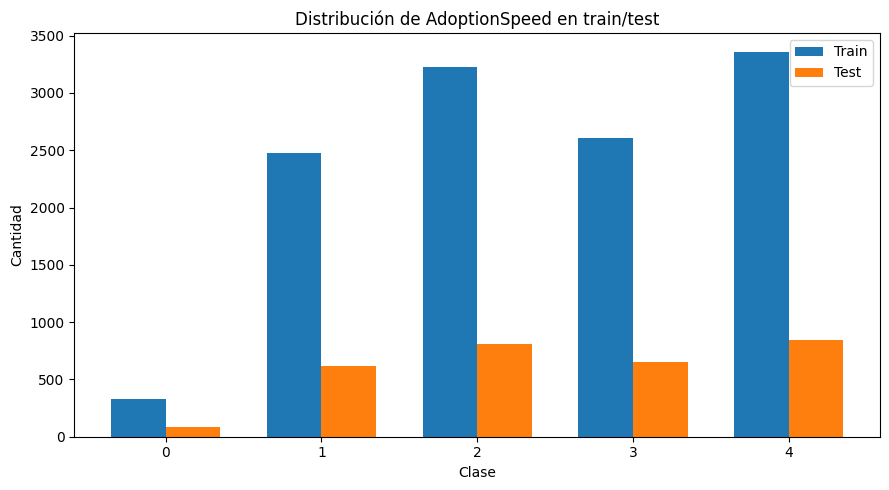

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\lgbm_enhanced_results\figures\01_distribucion_train_test.png


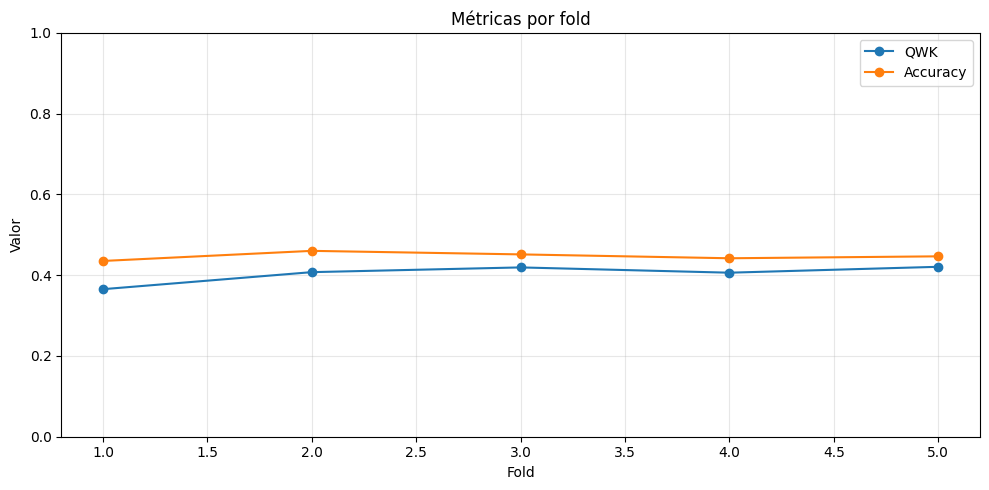

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\lgbm_enhanced_results\figures\02_metricas_por_fold.png


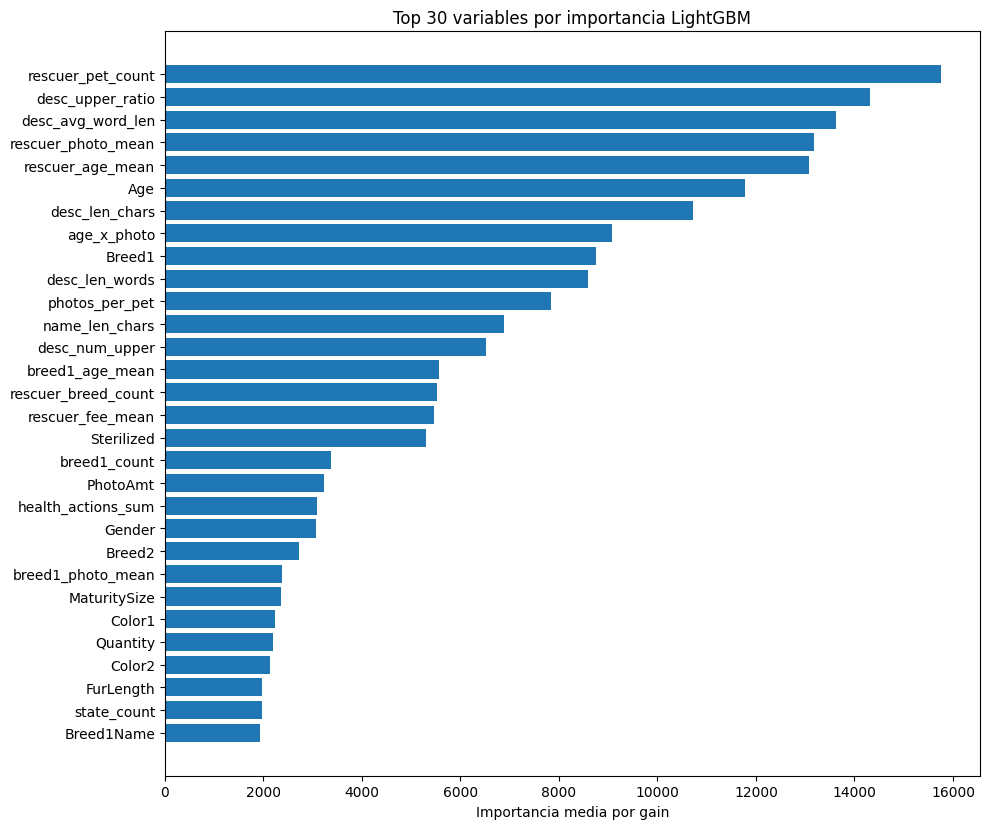

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\lgbm_enhanced_results\figures\03_feature_importance_gain.png


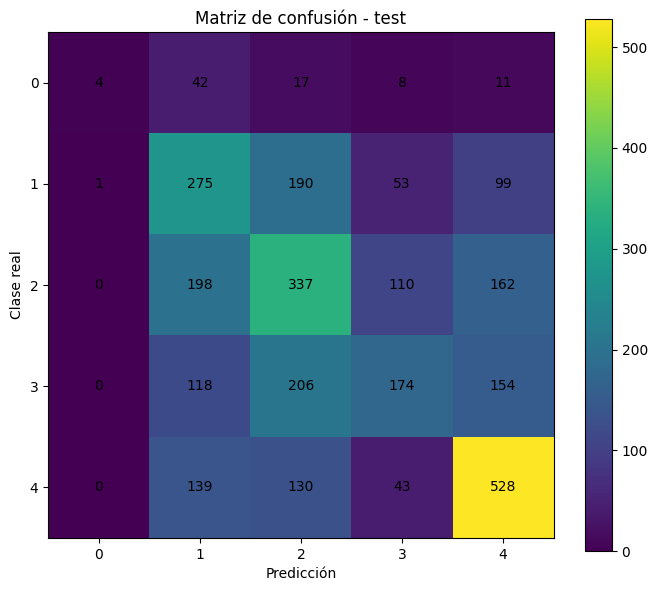

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\lgbm_enhanced_results\figures\04_confusion_matrix_test.png


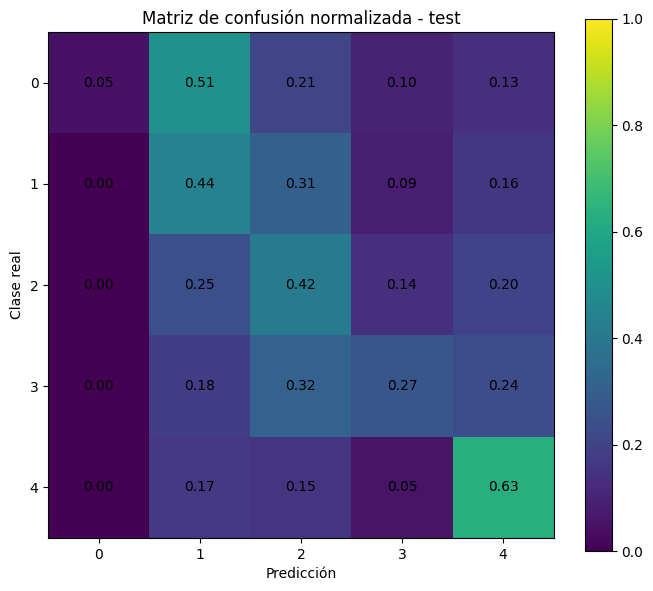

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\lgbm_enhanced_results\figures\05_confusion_matrix_normalizada_test.png


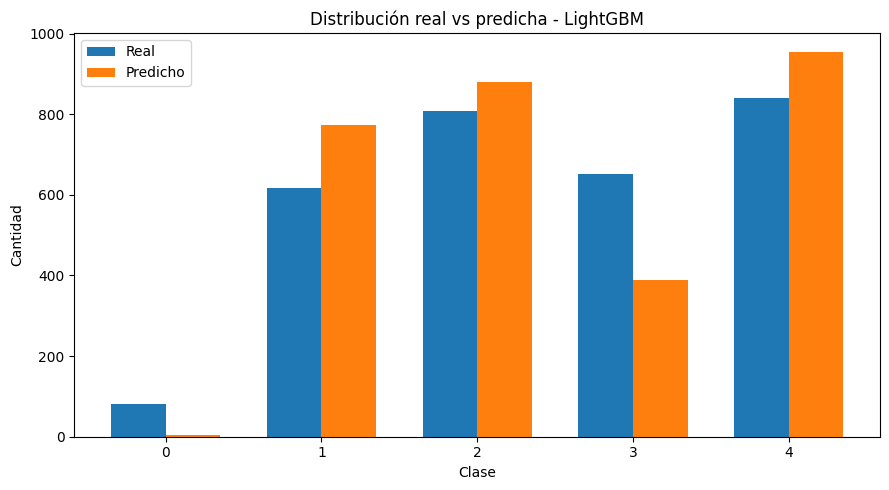

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\lgbm_enhanced_results\figures\06_distribucion_real_vs_predicha_test.png


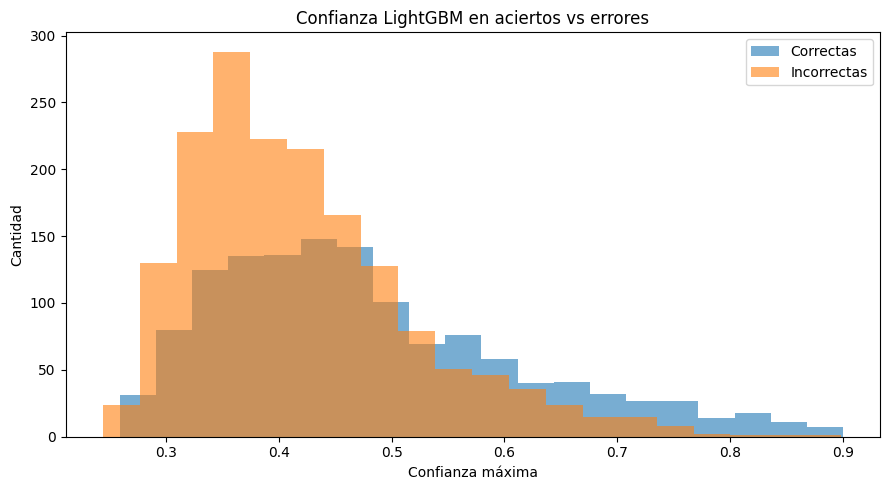

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\lgbm_enhanced_results\figures\07_confianza_aciertos_errores.png


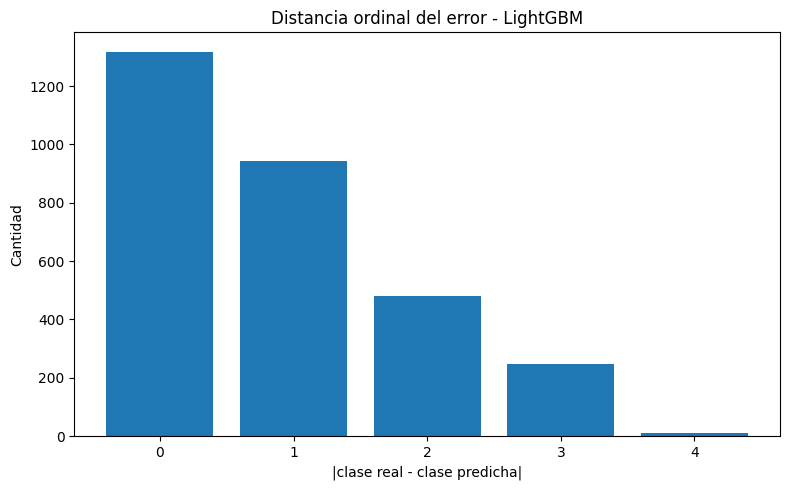

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\lgbm_enhanced_results\figures\08_distancia_ordinal_error.png

Listo. LightGBM mejorado queda preparado para integrarse con BERT.
Archivo principal de integración: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\optuna_artifacts\lgb_test_predictions.joblib


In [10]:
main()

## Cargar resultados ya generados

In [11]:
metrics = json.loads(PATH_LGB_METRICS.read_text(encoding="utf-8"))
fi = pd.read_csv(PATH_FEATURE_IMPORTANCE)
fold_metrics = pd.read_csv(PATH_FOLD_METRICS)
test_preds = load(PATH_LGB_TEST_PREDS)

print("Métricas test:")
print(metrics["test_metrics"])

print("\nTop 20 variables:")
display(fi.head(20))

print("\nMétricas por fold:")
display(fold_metrics)

print("\nPredicciones test:")
display(test_preds.head())


Métricas test:
{'model': 'LightGBM Test', 'n': 2999, 'qwk': 0.3737045308400142, 'accuracy': 0.43947982660886964, 'balanced_accuracy': 0.36136058709742225, 'f1_macro': 0.3620814817602016, 'f1_weighted': 0.4291788276500071, 'mae_class': 0.8956318772924308, 'rmse_class': 1.3236001306167167, 'adjacent_accuracy_1': 0.7542514171390463, 'adjacent_accuracy_2': 0.9143047682560853, 'log_loss': 1.2990721095138118, 'brier_multiclass': 0.6764732816195793, 'mean_confidence': 0.4451034793248347}

Top 20 variables:


,feature,importance_gain_mean,importance_gain_std,importance_split_mean,importance_split_std
0,rescuer_pet_count,15760.422673,563.712309,2489.6,227.577020
1,desc_upper_ratio,14320.425531,1422.725370,4248.6,592.796592
2,desc_avg_word_len,13626.368167,1685.278854,4170.0,701.441017
3,rescuer_photo_mean,13172.965777,1522.928379,3233.4,521.030997
4,rescuer_age_mean,13085.480602,1169.863192,3411.6,477.847570
5,Age,11780.883088,635.653294,1664.8,236.974049
6,desc_len_chars,10731.149206,1452.787768,3134.2,513.169270
7,age_x_photo,9067.409615,929.966741,2505.8,383.690891
8,Breed1,8754.490786,496.079031,1138.0,179.394816
9,desc_len_words,8587.364707,1071.265807,2526.8,456.846473



Métricas por fold:


,model,n,qwk,accuracy,balanced_accuracy,f1_macro,f1_weighted,mae_class,rmse_class,adjacent_accuracy_1,adjacent_accuracy_2,log_loss,brier_multiclass,mean_confidence,fold,best_iteration
0,fold_1,2399,0.365313,0.435181,0.351767,0.347787,0.415294,0.909546,1.340366,0.747395,0.914548,1.305863,0.676101,0.462772,1,126
1,fold_2,2399,0.407475,0.460192,0.374583,0.373174,0.444311,0.846603,1.282355,0.775740,0.927053,1.251877,0.655861,0.475388,2,181
2,fold_3,2399,0.419206,0.451438,0.367218,0.368479,0.434567,0.844935,1.263691,0.776574,0.933722,1.259116,0.658974,0.473200,3,164
3,fold_4,2399,0.406119,0.441851,0.352806,0.345380,0.424039,0.866194,1.286736,0.770321,0.929971,1.277159,0.668970,0.480936,4,181
4,fold_5,2398,0.420718,0.446622,0.369813,0.373476,0.430881,0.845288,1.266262,0.787323,0.928691,1.274812,0.663529,0.478583,5,185



Predicciones test:


,PetID,AdoptionSpeed,pred,lgb_pred_score,lgb_pred
0,8e76c8e39,1,"[0.029988776171498227, 0.5178997240470423, 0.2...","[0.029988776171498227, 0.5178997240470423, 0.2...",1
1,6436c1a59,2,"[0.0014471670975144606, 0.026222705022526962, ...","[0.0014471670975144606, 0.026222705022526962, ...",3
2,988988d5b,1,"[0.013459946325567589, 0.24943677639865736, 0....","[0.013459946325567589, 0.24943677639865736, 0....",3
3,efbf1703a,2,"[0.011040899018530406, 0.2878119762489778, 0.3...","[0.011040899018530406, 0.2878119762489778, 0.3...",2
4,543130f60,4,"[0.004301620631071796, 0.14103322380735656, 0....","[0.004301620631071796, 0.14103322380735656, 0....",4
